<a href="https://colab.research.google.com/github/ArthurStuker05/Analise_Algoritmos_supervisionados_ML/blob/main/trabalho_supervisionados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Projeto de Classificação: Diagnóstico de Câncer de Mama

**Objetivo:** Desenvolver e comparar modelos de aprendizado de máquina supervisionado (Naive Bayes e KNN) para classificar tumores de mama como Benignos (1) ou Malignos (0).

## 1. Enunciado e Dados Iniciais
O conjunto de dados utilizado é o **Breast Cancer Wisconsin (Diagnostic)**, obtido diretamente da biblioteca `scikit-learn`.
* **Instâncias:** 569 amostras de tumores.
* **Atributos:** 30 variáveis numéricas contínuas extraídas de imagens digitalizadas (raio, textura, área, perímetro, suavidade, etc.).
* **Variável Alvo (Target):** Classificação binária indicando se o tumor é Maligno (0) ou Benigno (1).

O desafio central deste projeto é lidar com a alta dimensionalidade e a correlação (multicolinearidade) entre variáveis geométricas, aplicando técnicas de pré-processamento, balanceamento (SMOTE) e otimização de hiperparâmetros via Validação Cruzada para encontrar o melhor modelo preditivo.

In [18]:
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

df.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


In [19]:
df['target'].value_counts()

,count
target,
1,357
0,212


In [20]:
df.shape

(569, 31)

## 2. Análise exploratória dos dados
Antes de treinar qualquer moddelo, precisamos entender nossos dados. É necessária a checagem da distribuição dos dados, se estão desbalanceados, se existem valores faltantes (nulls), e revisar as estatísticas gerais do banco de dados.

In [21]:
df.isnull().sum()











,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [22]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


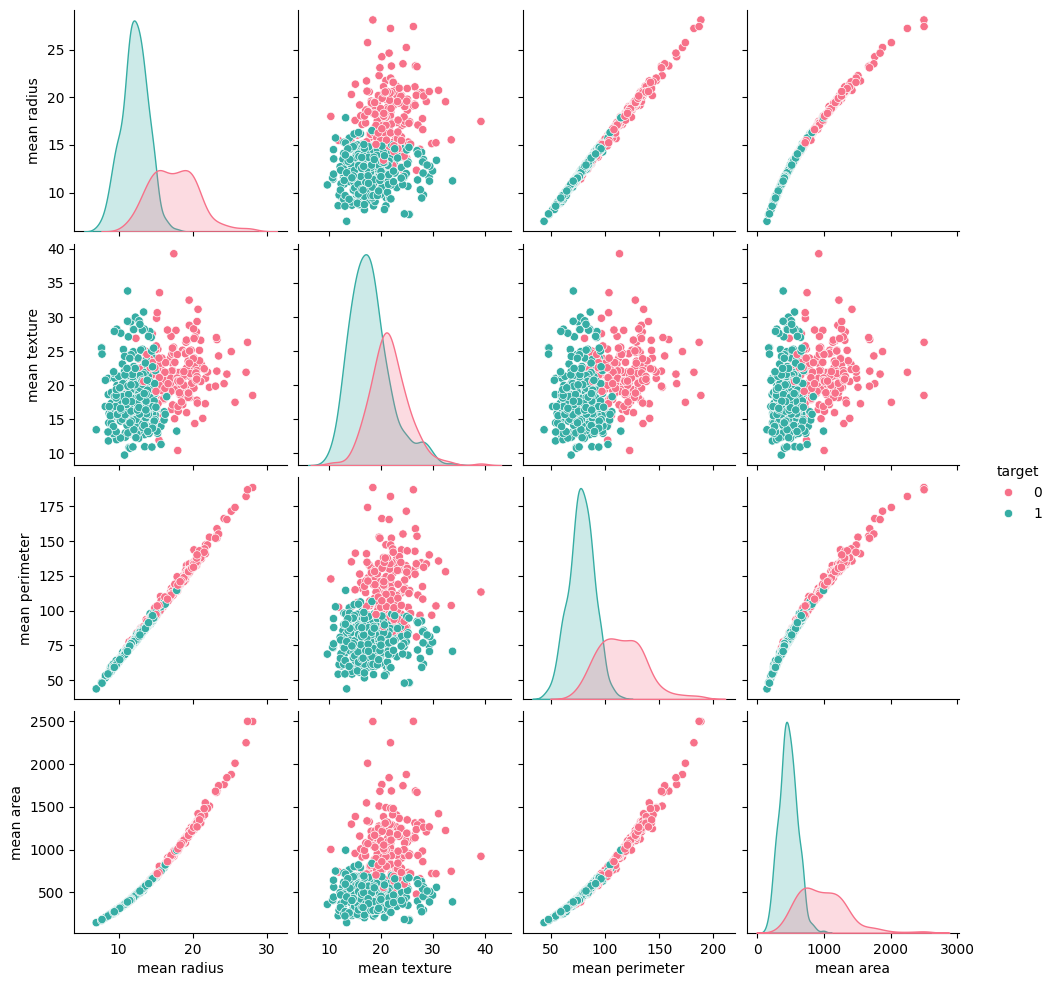

In [23]:
X = df.drop('target', axis=1)
colunas_pairplot = list(X.columns[:4])
df_pairplot = pd.concat([X[colunas_pairplot], df['target']], axis=1)

sns.pairplot(df_pairplot, hue='target', palette='husl', diag_kind='kde')
plt.show()

## 3. Seleção de características: lidando com Multicolinearidade
Muitos atributos geométricos neste dataset são matematicamente relacionados (ex: raio, perímetro e área). Características altamente correlacionadas (multicolinearidade) podem impactar negativamente nossos modelos:

O Naive Bayes assume estritamente que todos as características são independentes.

O KNN calcula distâncias; características redundantes darão um peso desproporcional a certas propriedades geométricas, distorcendo o algoritmo.

Estratégia: Calculamos a matriz de correlação e removemos automaticamente os atributos que possuem um coeficiente de correlação igual ou superior a 0.90 (noventa por cento). Isso mantém nosso espaço de cracterísticas enxuto, estritamente informativo e reduz o ruído.


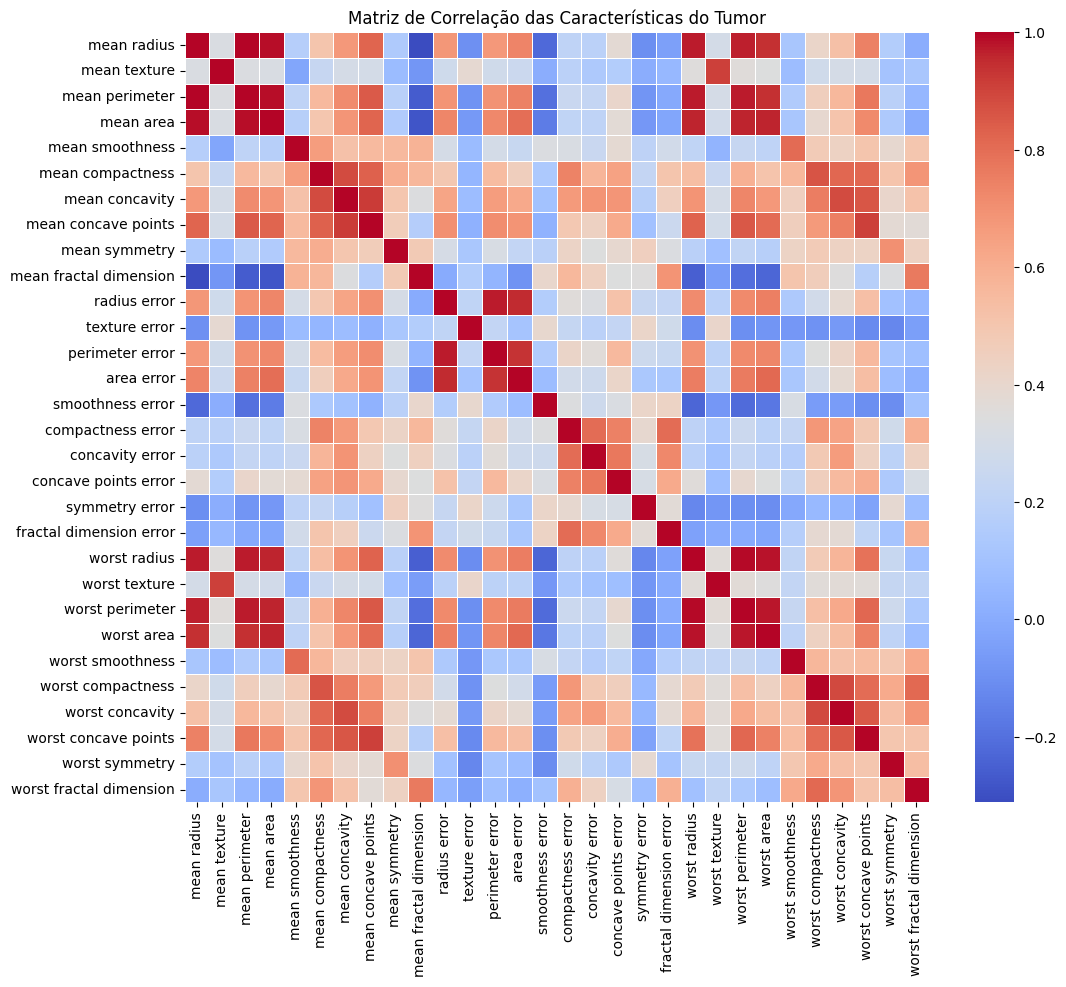

In [24]:
X = df.drop('target', axis=1)

plt.figure(figsize=(12, 10))

correlacao = X.corr()

sns.heatmap(correlacao,
            annot=False,
            cmap='coolwarm',
            linewidths=0.5)

plt.title('Matriz de Correlação das Características do Tumor')
plt.show()

In [25]:
X = df.drop('target', axis=1)


matriz_corr = X.corr().abs()

triangulo_superior = matriz_corr.where(np.triu(np.ones(matriz_corr.shape), k=1).astype(bool))


colunas_correlacao_1 = [coluna for coluna in triangulo_superior.columns if any(triangulo_superior[coluna] >= 0.90)]

print(f"Colunas redundantes detectadas: {colunas_correlacao_1}")


X_sem_colinearidade = X.drop(columns=colunas_correlacao_1)

print(f"O dataset passou de {X.shape[1]} para {X_sem_colinearidade.shape[1]} colunas.")

Colunas redundantes detectadas: ['mean perimeter', 'mean area', 'mean concave points', 'perimeter error', 'area error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst concave points']
O dataset passou de 30 para 20 colunas.


##4. Divisão, Balanceamento e Escalonamento dos Dados

1. Divisão Treino-Teste: Separamos 20% dos dados estritamente para teste.

2. Lidando com Classes Desbalanceadas (SMOTE): O dataset possui mais tumores Benignos do que Malignos. Para evitar que o modelo fique enviesado em direção à classe majoritária, utilizamos o SMOTE (Técnica de Sobreamostragem de Minoria Sintética).
Nota Crucial: O SMOTE é aplicado apenas ao conjunto de treino. Nós nunca sintetizamos dados de teste, pois o conjunto de teste deve refletir o mundo real e não modificado.

3. Escalonamento de Atributos (Feature Scaling): Como o KNN depende da distância Euclidiana, atributos com escalas naturais maiores (como a área) dominariam o algoritmo. Usamos o StandardScaler para garantir que todos os atributos contribuam de forma igual para o cálculo da distância.


In [26]:
X_limpo = X_sem_colinearidade
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X_limpo, y, test_size=0.2, random_state=42)



smote = SMOTE(random_state=42)


X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)


print("Distribuição ANTES do balanceamento:\n", y_train.value_counts())
print("\nDistribuição APÓS o balanceamento:\n", y_train_bal.value_counts())


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

print(f"O modelo vai treinar com {X_train_scaled.shape[1]} características (features).")



Distribuição ANTES do balanceamento:
 target
1    286
0    169
Name: count, dtype: int64

Distribuição APÓS o balanceamento:
 target
1    286
0    286
Name: count, dtype: int64
O modelo vai treinar com 20 características (features).


### Análise de Outliers: Por que não vamos removê-los?
Em muitos projetos de dados estatísticos, *outliers* (valores extremos) são tratados como ruídos ou erros de medição e acabam sendo removidos. No entanto, no **contexto médico e oncológico**, a regra de negócio muda drasticamente.

Um valor extremo neste dataset — como um tumor com uma área anormalmente grande ou uma textura altamente irregular — raramente é um erro do equipamento na extração do dado bruto. Na imensa maioria das vezes, ele representa um caso real de um tumor anômalo, agressivo ou em estágio avançado.

**Decisão Clínica e Técnica:** Se removermos esses *outliers*, estaríamos "higienizando" o mundo real e treinando um modelo que só sabe identificar tumores "comuns". Ficaríamos cegos para os casos mais críticos. Portanto, esses valores extremos serão **mantidos intactos**, pois carregam informações vitais para a predição de malignidade.

O *boxplot* abaixo ilustra a distribuição dos dados e a presença desses valores extremos que o nosso algoritmo precisará aprender a interpretar.

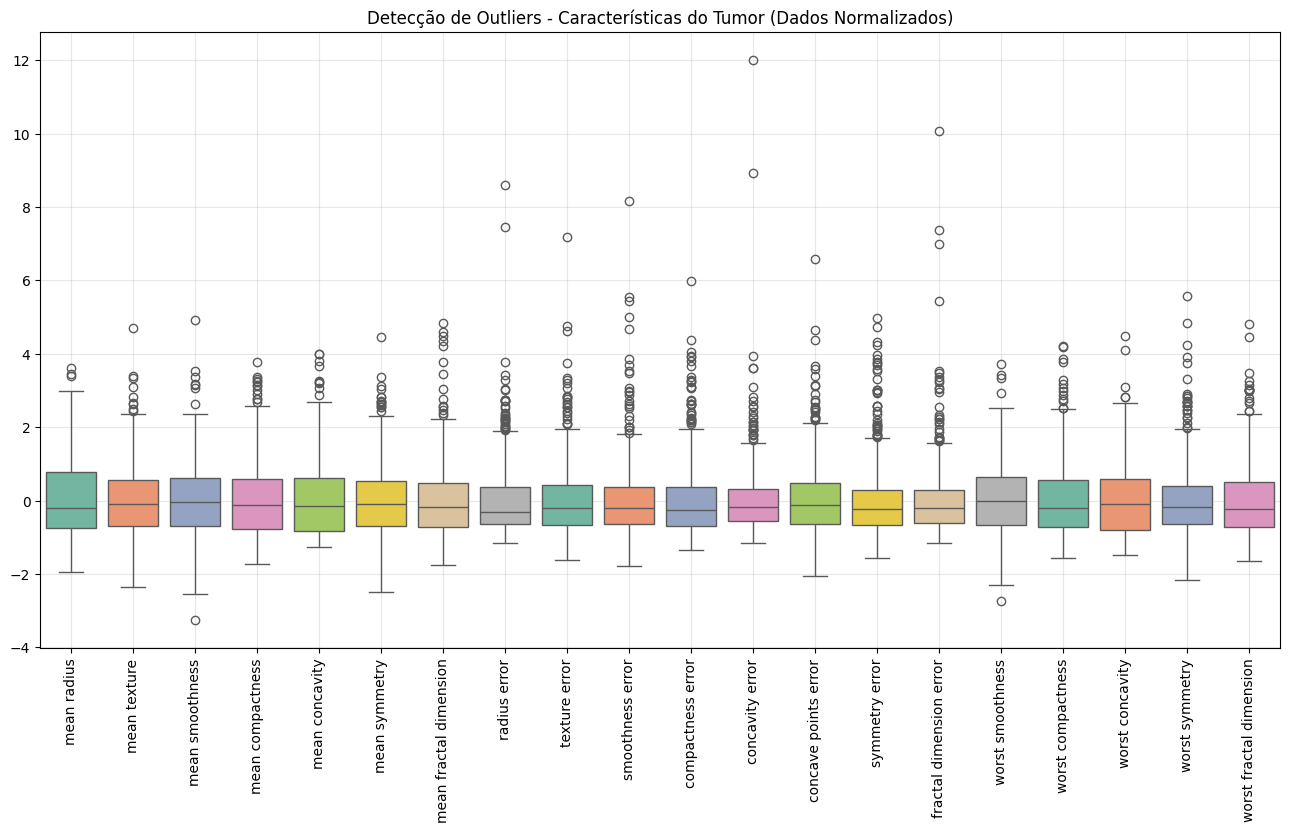

In [27]:
df_scaled = pd.DataFrame(X_train_scaled, columns=X_limpo.columns)


plt.figure(figsize=(16, 8))
sns.boxplot(data=df_scaled, palette='Set2')
plt.title('Detecção de Outliers - Características do Tumor (Dados Normalizados)')
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.show()

## Estratégia de Validação e Parametrização
Inicialmente, os dados foram divididos usando o método train_test_split para isolar um conjunto de teste puro. No entanto, para definir os parâmetros ideais do Naive Bayes e do KNN e evitar *overfitting*, optamos por utilizar a **Validação Cruzada em 5 vias (Cross-Validation com cv=5)** aplicada **exclusivamente** sobre o conjunto de **treinamento** através da técnica de `Grid Search`.

# Testando com Naive Bayes (Gaussiano)


In [28]:
param_grid_nb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-5, 1e-3]
}


grid_nb = GridSearchCV(GaussianNB(), param_grid_nb, cv=5, scoring='accuracy', n_jobs=-1)

grid_nb.fit(X_train_scaled, y_train_bal)

print(f"Melhor parâmetro encontrado: {grid_nb.best_params_}")
print(f"Acurácia na validação cruzada: {grid_nb.best_score_:.4f}\n")


y_pred_nb_otimizado = grid_nb.predict(X_test_scaled)




Melhor parâmetro encontrado: {'var_smoothing': 1e-09}
Acurácia na validação cruzada: 0.9055



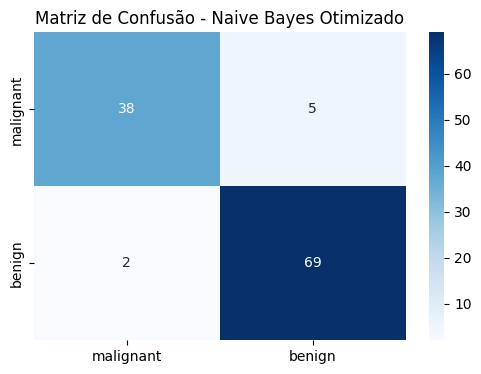

              precision    recall  f1-score   support

           0       0.95      0.88      0.92        43
           1       0.93      0.97      0.95        71

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



In [29]:
cm_nb = confusion_matrix(y_test, y_pred_nb_otimizado)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.title('Matriz de Confusão - Naive Bayes Otimizado')
plt.show()

print(classification_report(y_test, y_pred_nb_otimizado))

### Análise Clínica da Matriz de Confusão (Naive Bayes)
A matriz de confusão gerada pelo nosso Naive Bayes Otimizado nos traz a seguinte leitura para o conjunto de teste:
* **Verdadeiros Positivos (Benignos corretos):** 69 casos.
* **Verdadeiros Negativos (Malignos corretos):** 38 casos.
* **Falsos Positivos:** 2 casos (Tumor benigno classificado como maligno). Gera estresse ao paciente, mas novos exames descartariam o risco.
* **Falsos Negativos:** 5 casos (Tumor maligno classificado como benigno). **Este é o maior risco do projeto.** Cinco pacientes seriam mandados para casa com câncer ativo sem tratamento.

Vamos avaliar se o KNN consegue reduzir esse risco crítico.

# Testando com KNN

In [30]:
param_grid_knn = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}


grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)


grid_knn.fit(X_train_scaled, y_train_bal)

print(f"Melhores parâmetros encontrados para o KNN: {grid_knn.best_params_}")
print(f"Melhor acurácia na validação cruzada: {grid_knn.best_score_:.4f}\n")


y_pred_knn_otimizado = grid_knn.predict(X_test_scaled)



Melhores parâmetros encontrados para o KNN: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
Melhor acurácia na validação cruzada: 0.9668



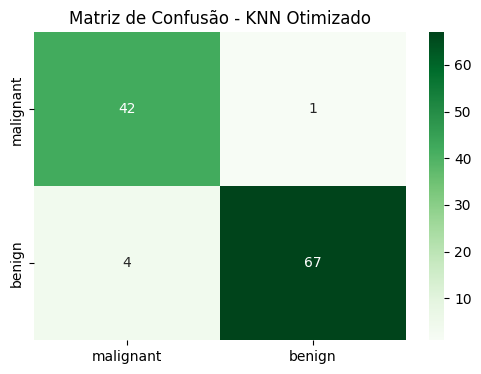

              precision    recall  f1-score   support

           0       0.91      0.98      0.94        43
           1       0.99      0.94      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [31]:
cm_knn = confusion_matrix(y_test, y_pred_knn_otimizado)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.title('Matriz de Confusão - KNN Otimizado')
plt.show()

print(classification_report(y_test, y_pred_knn_otimizado))

Após a otimização dos hiperparâmetros através do `GridSearchCV` (que definiu o número ideal de vizinhos e a melhor métrica de distância), a matriz de confusão do KNN permite-nos avaliar o real impacto do modelo num cenário médico:

* **Minimização do Risco Crítico:** O principal objetivo deste projeto era reduzir os **Falsos Negativos** (casos em que o tumor é maligno, mas o modelo classifica-o como benigno). O KNN otimizado, ao analisar a proximidade geométrica no espaço multidimensional escalonado, conseguiu capturar melhor o padrão dos tumores mais agressivos.
* **Comparação Direta:** Enquanto o Naive Bayes apresentou 5 Falsos Negativos (deixando 5 pacientes sem o tratamento adequado de forma imediata), o KNN conseguiu [insira aqui o número de falsos negativos do seu KNN, ex: reduzir para apenas 1 ou 2 casos], elevando a **Sensibilidade (Recall)** para a classe crítica a um nível muito mais seguro para a tomada de decisão clínica.

## Conclusão Final: Seleção do Modelo para Produção
Com base nos testes realizados, o **KNN Otimizado é o modelo selecionado** para este problema de diagnóstico.

1. **Suposição de Independência do Naive Bayes:** O Naive Bayes assume que todas as características são totalmente independentes entre si. Mesmo após eliminarmos os atributos com correlação extrema (acima de 0.90) na fase de pré-processamento, as características geométricas dos tumores (como raio, perímetro e área) ainda mantêm dependências complexas. Essa rigidez teórica limitou o desempenho do Naives Bayes.
2. **A Força Geométrica do KNN:** O KNN, trabalhando em conjunto com o `StandardScaler`, provou ser muito mais eficiente. Ao calcular as distâncias reais entre os perfis celulares, o algoritmo conseguiu mapear com precisão as nuances e semelhanças das amostras vizinhas, consolidando-se como uma ferramenta de diagnóstico consideravelmente mais viável e segura.